# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [107]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [108]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
# Write your code here to read the data
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PGP_AIML_McCombs/EDA/Project/foodhub_order.csv")
# copy the data for analysis
df = data.copy()

In [110]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [111]:
# Write your code here
# Check the dataframe shape
df.shape

(1898, 9)

#### Observations:
* There are 1898 rows and 9 columns in the dataset.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [112]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
* Columns order_id, customer_id, food_preparation_time and delivery_time are of integer type.
* Column cost_of_the_order is of float type.
* Columns restaurant_name, cuisine_type, day_of_the_week and rating are of Object data type indicating string values.

**Note**: rating column is identified as an object datatype due to the presence of string value **'Not given'**.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [113]:
# Write your code here
# Check NaN/missing values
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [114]:
# checking unique values in the categorical columns to identify missing values provided as text instead of nan
cat_cols = ['restaurant_name', 'cuisine_type', 'day_of_the_week', 'rating']
for col in cat_cols:
  print(f"Unique values in {col}: {df[col].unique()}")

Unique values in restaurant_name: ['Hangawi' 'Blue Ribbon Sushi Izakaya' 'Cafe Habana'
 'Blue Ribbon Fried Chicken' 'Dirty Bird to Go' 'Tamarind TriBeCa'
 'The Meatball Shop' 'Barbounia' 'Anjappar Chettinad' 'Bukhara Grill'
 'Big Wong Restaurant \x8c_¤¾Ñ¼' 'Empanada Mama (closed)' 'Pylos'
 "Lucky's Famous Burgers" 'Shake Shack' 'Sushi of Gari' 'RedFarm Hudson'
 'Blue Ribbon Sushi' 'Five Guys Burgers and Fries' 'Tortaria'
 'Cafe Mogador' 'Otto Enoteca Pizzeria' 'Vezzo Thin Crust Pizza'
 'Sushi of Gari 46' 'The Kati Roll Company' 'Klong' '5 Napkin Burger'
 'TAO' 'Parm' 'Sushi Samba' 'Haru Gramercy Park'
 'Chipotle Mexican Grill $1.99 Delivery' 'RedFarm Broadway' 'Cafeteria'
 'DuMont Burger' "Sarabeth's East" 'Hill Country Fried Chicken' 'Bistango'
 "Jack's Wife Freda" "Mamoun's Falafel" 'Prosperity Dumpling'
 'Blue Ribbon Sushi Bar & Grill' 'Westville Hudson' 'Blue Ribbon Brooklyn'
 'Nobu Next Door' 'Osteria Morini' 'Haandi' 'Benihana' 'Han Dynasty'
 'Chote Nawab' 'Mission Cantina' "Xi'a

In [115]:
# finding the count of missing values considering 'Not given' in rating column as nan value
df_missing_treat = df.copy()
df_missing_treat['rating'] = df_missing_treat['rating'].replace('Not given', np.nan)
df_missing_treat['rating'] = df_missing_treat['rating'].astype(float)
df_missing_treat.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


In [116]:
# treating the missing ratings by imputing with avg rating by restaurant_name
df_missing_treat['rating'] = df_missing_treat.groupby('restaurant_name')['rating'].transform(lambda x: x.fillna(x.mean()))
df_missing_treat.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,30
food_preparation_time,0
delivery_time,0


In [117]:
# find the restaurant names with missing ratings after imputation
res_mis_rating = df_missing_treat[df_missing_treat['rating'].isnull()]['restaurant_name'].unique()
print(f"No. of restaurants without ratings after imputation: {len(res_mis_rating)}")

No. of restaurants without ratings after imputation: 22


In [118]:
# percentage of null values
df_missing_treat.isnull().sum()/df_missing_treat.shape[0]*100

,0
order_id,0.00
customer_id,0.00
restaurant_name,0.00
cuisine_type,0.00
cost_of_the_order,0.00
day_of_the_week,0.00
rating,1.58
food_preparation_time,0.00
delivery_time,0.00


In [119]:
# the percentage of missing ratings is minimal (1.5%) and we can drop the rows with missing values
df_missing_treat.dropna(inplace=True)
df_missing_treat.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [120]:
# converting ratings to int and checking the shape of df after missing value treatement
df_missing_treat['rating'] = df_missing_treat['rating'].astype(int)
df_missing_treat.shape

(1868, 9)

#### Observations:
* There are 736 missing values in the rating column which are ideally the orders that aren't rated.
* No ratings are available for 22 restaurants, there are only 30 orders placed across these restaurants in total ranging between 1 to 3 orders per restaurant.
* Imputed the missing values for ratings by mean of restaurant ratings where available, and dropped the rows for restaurants without any rating which constitutes only 1.5% orders.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [121]:
# Write your code here
# new column for total fulfillment time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# format to 2 decimals and check statistical summary
pd.options.display.float_format = '{:.2f}'.format
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
order_id,1898.00,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.00,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.00,16.50,7.48,4.47,12.08,14.14,22.30,35.41
food_preparation_time,1898.00,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.00,24.16,4.97,15.00,20.00,25.00,28.00,33.00
total_time,1898.00,51.53,6.83,35.00,47.00,52.00,56.00,68.00


#### Observations:
* Food preparation time ranges from a minimum of 20 mins to a maximum of 35 mins with an average of 27.37 mins per order.  
* Preparation time for 75% of the orders is greater than 23 mins.  
* Total time from order to delivery ranges from a minimum of 35 mins to a maximum of 68 mins with an average of 51.53 mins per order.  

### **Question 5:** How many orders are not rated? [1 mark]

In [122]:
# Write the code here
# find the number of orders with rating 'Not given'
orders_not_rated_count = df[df['rating'] == 'Not given'].shape[0]
orders_not_rated_percent = (orders_not_rated_count/df.shape[0])*100
print(f"No. of orders not rated: {orders_not_rated_count}")
print(f"Percentage of orders not rated: {orders_not_rated_percent:.2f}%")

No. of orders not rated: 736
Percentage of orders not rated: 38.78%


#### Observations:
* 736 (38.78%) orders aren't rated.

### Exploratory Data Analysis (EDA)

## Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [123]:
# Write the code here
# display cloumn names
df.columns.to_list()

['order_id',
 'customer_id',
 'restaurant_name',
 'cuisine_type',
 'cost_of_the_order',
 'day_of_the_week',
 'rating',
 'food_preparation_time',
 'delivery_time',
 'total_time']

### Numerical Vars

#### Cost of the Order

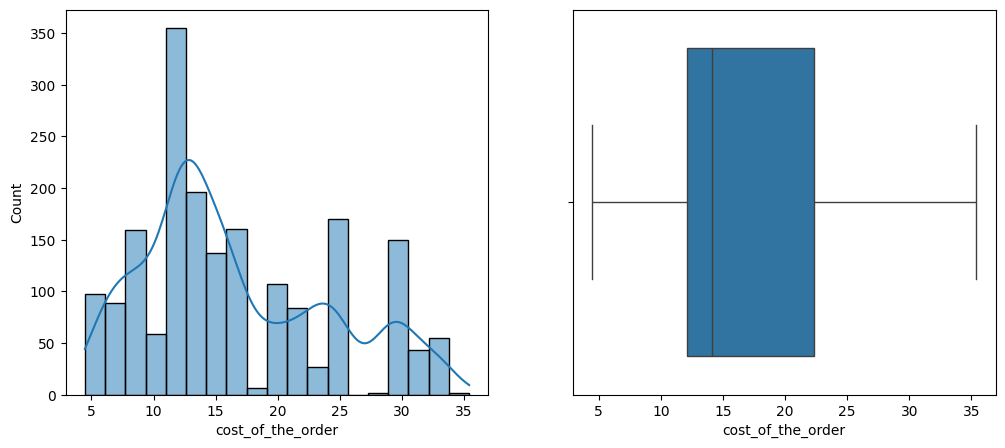

Min cost: $4.47
Max cost: $35.41
Mean cost: $16.50
Median cost: $14.14
Standard Deviation: 7.48


In [124]:
# setup to display plots next to each other
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# plot histogram and boxplot for order cost
sns.histplot(data=df, x='cost_of_the_order', kde=True, ax=axes[0])
sns.boxplot(data=df, x='cost_of_the_order', ax=axes[1])
plt.show()

# measures of central tendency
print(f"Min cost: ${df['cost_of_the_order'].min():.2f}")
print(f"Max cost: ${df['cost_of_the_order'].max():.2f}")
print(f"Mean cost: ${df['cost_of_the_order'].mean():.2f}")
print(f"Median cost: ${df['cost_of_the_order'].median():.2f}")
print(f"Standard Deviation: {df['cost_of_the_order'].std():.2f}")

#### Observations:

- Order costs range from \$4.47 to \$35.41 dollars.  
- Avg. cost per order is \$16.50 with standard deviation of 7.48
- Median cost is \$14.14
- The cost distribution is **right-skewed** (positively skewed) with most orders concentrated between 10 to 20 dollars

#### Food preparation time

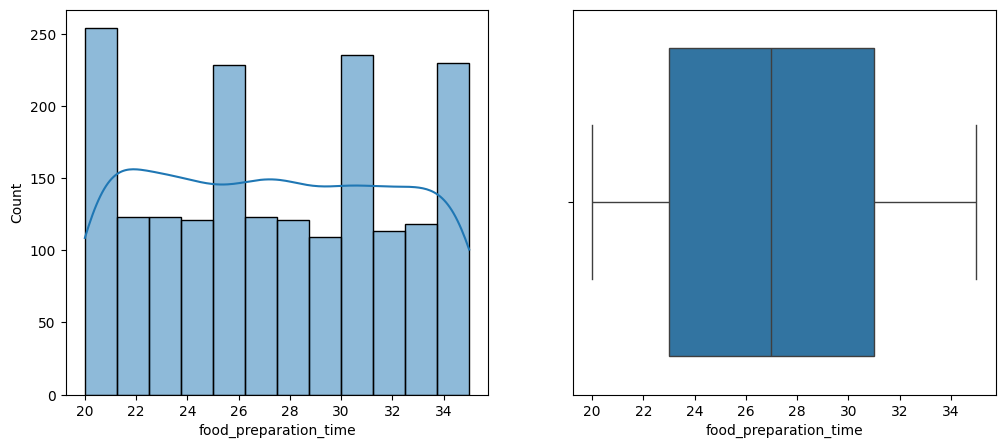

Min preparation time: 20 mins
Max preparation time: 35 mins
Mean preparation time: 27.37 mins
Median preparation time: 27.0 mins
Standard Deviation: 4.63


In [125]:
# setup subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# plot historgram and boxplot for food preparation time
sns.histplot(data=df, x='food_preparation_time', kde=True, ax=axes[0])
sns.boxplot(data=df, x='food_preparation_time', ax=axes[1])
plt.show()

# measures of central tendency
print(f"Min preparation time: {df['food_preparation_time'].min()} mins")
print(f"Max preparation time: {df['food_preparation_time'].max()} mins")
print(f"Mean preparation time: {df['food_preparation_time'].mean():.2f} mins")
print(f"Median preparation time: {df['food_preparation_time'].median()} mins")
print(f"Standard Deviation: {df['food_preparation_time'].std():.2f}")

#### Observations:
- Food preparation time ranges from 20 to 35 mins
- Average preparation time is 27.37 mins with standard deviation of 4.63
- Median preparation time is 27 mins
- The mean and median are close, resulting in a mostly symmetric distribution
- Most restaurants are consistent with preparation time typically taking around 25 to 30 mins

#### Delivery Time

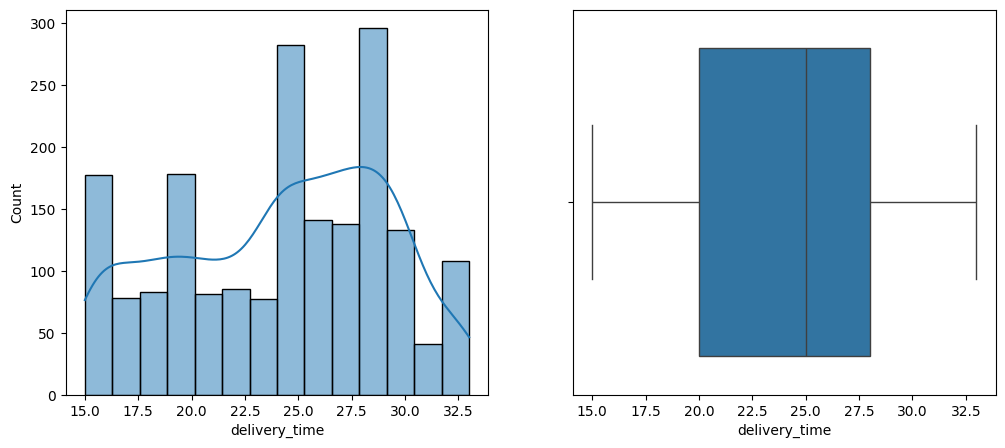

Min delivery time: 15 mins
Max delivery time: 33 mins
Mean delivery time: 24.16 mins
Median delivery time: 25.0 mins
Standard Deviation: 4.97


In [126]:
# configure subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# plot histogram and boxplot for delivery time
sns.histplot(data=df, x='delivery_time', kde=True, ax=axes[0])
sns.boxplot(data=df, x='delivery_time', ax=axes[1])
plt.show()

# measures of central tendency
print(f"Min delivery time: {df['delivery_time'].min()} mins")
print(f"Max delivery time: {df['delivery_time'].max()} mins")
print(f"Mean delivery time: {df['delivery_time'].mean():.2f} mins")
print(f"Median delivery time: {df['delivery_time'].median()} mins")
print(f"Standard Deviation: {df['delivery_time'].std():.2f}")

#### Observations:
- Delivery times range from 15 to 33 mins
- Average delivery time is 24.16 mins with standard deviation of 4.97
- Median time is 25 mins
- The distribution is mild **left-skewed**


#### Total Order to Delivery time

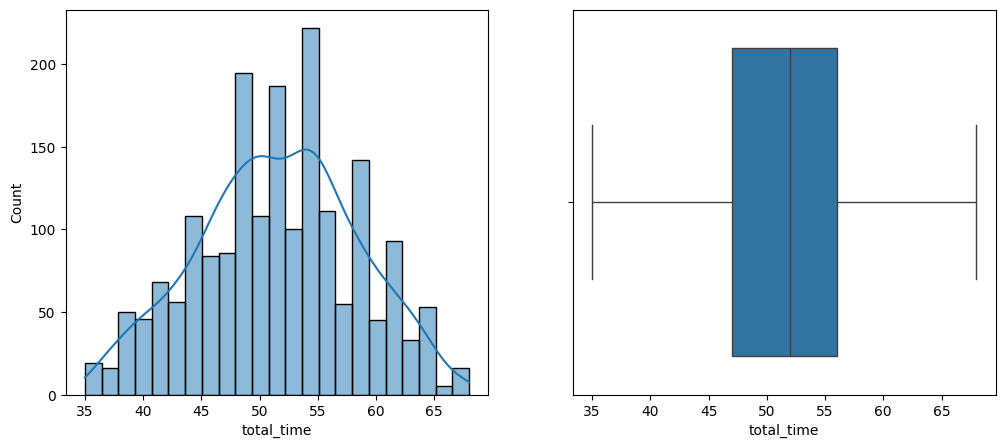

Min total time: 35 mins
Max total time: 68 mins
Mean total time: 51.53 mins
Median total time: 52.0 mins
Standard Deviation: 6.83


In [127]:
# configure subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# plot histogram and boxplot for total fulfillment time
sns.histplot(data=df, x='total_time', kde=True, ax=axes[0])
sns.boxplot(data=df, x='total_time', ax=axes[1])
plt.show()

# measures of central tendency
print(f"Min total time: {df['total_time'].min()} mins")
print(f"Max total time: {df['total_time'].max()} mins")
print(f"Mean total time: {df['total_time'].mean():.2f} mins")
print(f"Median total time: {df['total_time'].median()} mins")
print(f"Standard Deviation: {df['total_time'].std():.2f}")

#### Observations:
- Total order to delivery times range from 35 to 68 mins
- Average time is 51.53 mins with standard deviation of 6.83
- Median time is 52 mins
- 75% of the orders are fulfilled within 56 mins
- Approximately normal distribution centered around 50 to 55 mins

### Categorical Vars

#### Order Id

In [128]:
# Unique Orders count
num_orders = df['order_id'].nunique()
print(f"No. of orders: {num_orders}")

No. of orders: 1898


#### Observations:
- There are no duplicate orders in the dataset
- Total orders placed is 1898

#### Customer Id

In [129]:
# Number of unique customers
df['customer_id'].nunique()
print(f"No. of unique customers: {df['customer_id'].nunique()}")

No. of unique customers: 1200


#### Observations:
- The orders are placed by 1200 customers, this indicates repeated customer orders.

#### Restaurant Name

No. of unique restaurants: 178


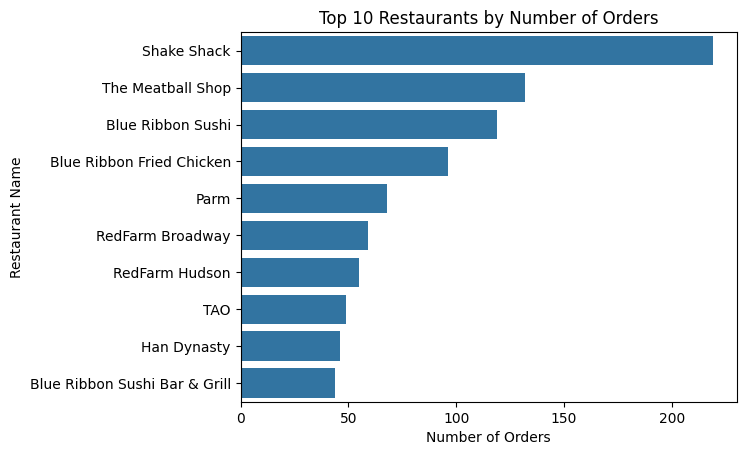

In [130]:
# Number of restaurants
uniq_restaurants = df['restaurant_name'].nunique()
print(f"No. of unique restaurants: {uniq_restaurants}")

# Top restaurants by orders
top_restaurants = df['restaurant_name'].value_counts().head(10)

# countplot for toop 10 restaurants
sns.countplot(df, y='restaurant_name', order=top_restaurants.index);
plt.title('Top 10 Restaurants by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Restaurant Name')
plt.show()

#### Observations:
- Total number of restaurants is 178
- Top 3 restaurants by orders: Shake Shack, The Meatball Shop and Blue Ribbon Sushi

#### Cuisine Type

No. of unique cuisine types: 14


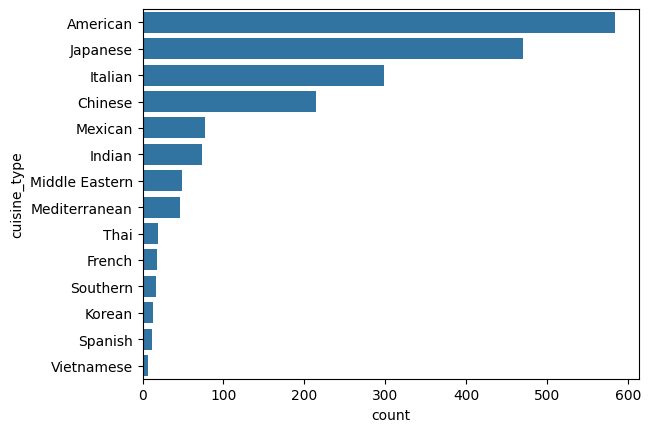

In [131]:
# Cuisine types
uniq_cuisine_types = df['cuisine_type'].nunique()
print(f"No. of unique cuisine types: {uniq_cuisine_types}")

# Top cuisine types
cuisine_types_by_orders = df['cuisine_type'].value_counts()
sns.countplot(df, y='cuisine_type', order=cuisine_types_by_orders.index);

#### Observations:
- There are 14 cuisine types in total
- American, Japanese, Italian and Chinese cuisines constitute majority of orders

#### Day of the Week

In [132]:
# proporation of orders by day of the week
df['day_of_the_week'].value_counts(normalize=True).reset_index()

,day_of_the_week,proportion
0,Weekend,0.71
1,Weekday,0.29


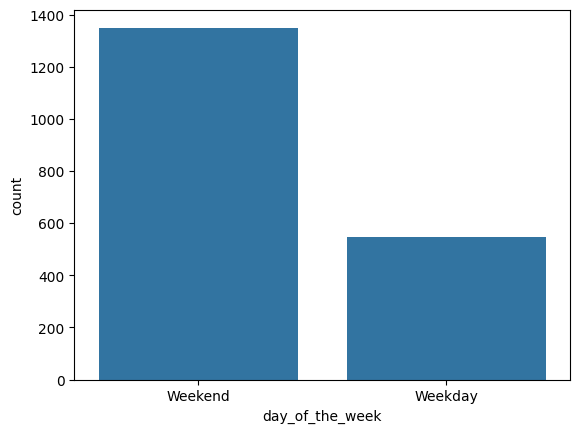

In [133]:
# number of orders by day of the week
sns.countplot(df, x='day_of_the_week');

#### Observations:
- Majority (71%) of the orders are placed during the Weekend
- Only 29% of the orders are placed during the Weekdays

#### Rating

In [134]:
# proportion of ratings
df['rating'].value_counts(normalize=True).reset_index()

,rating,proportion
0,Not given,0.39
1,5,0.31
2,4,0.20
3,3,0.10


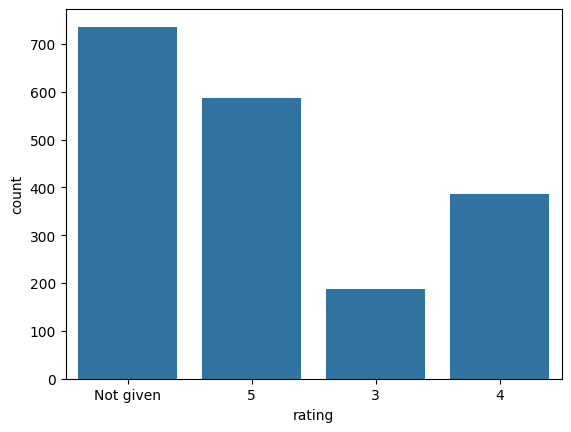

In [135]:
# number of orders by rating
sns.countplot(df, x='rating');

#### Observations:
- 39% of the orders are not rated, this requires missing value treatement
- 31% of the orders are rated 5 and 20% are rated 4

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [136]:
# Write the code here
# Top 5 restaurants by orders and their proportion of orders
top_5_restaurants = df['restaurant_name'].value_counts(normalize=True).head(5)
top_5_restaurants.reset_index()

,restaurant_name,proportion
0,Shake Shack,0.12
1,The Meatball Shop,0.07
2,Blue Ribbon Sushi,0.06
3,Blue Ribbon Fried Chicken,0.05
4,Parm,0.04


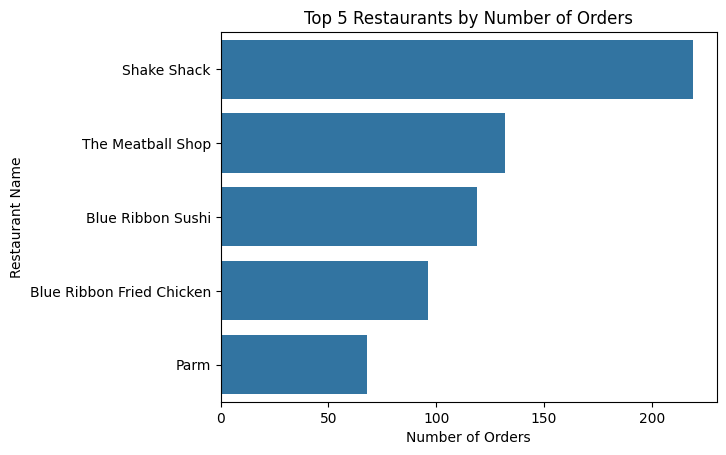

In [137]:
# plot number of orders received by top 5 restaurants
sns.countplot(data=df, y='restaurant_name', order=top_5_restaurants.index);
plt.title('Top 5 Restaurants by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Restaurant Name')
plt.show()

#### Observations:
- 34% of the orders are fulfilled by top 5 restaurants
- Top 5 Restaurants by orders:
    1) Shake Shack
    2) The Meatball Shop
    3) Blue Ribbon Sushi
    4) Blue Ribbon Fried Chicken
    5) Parm


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

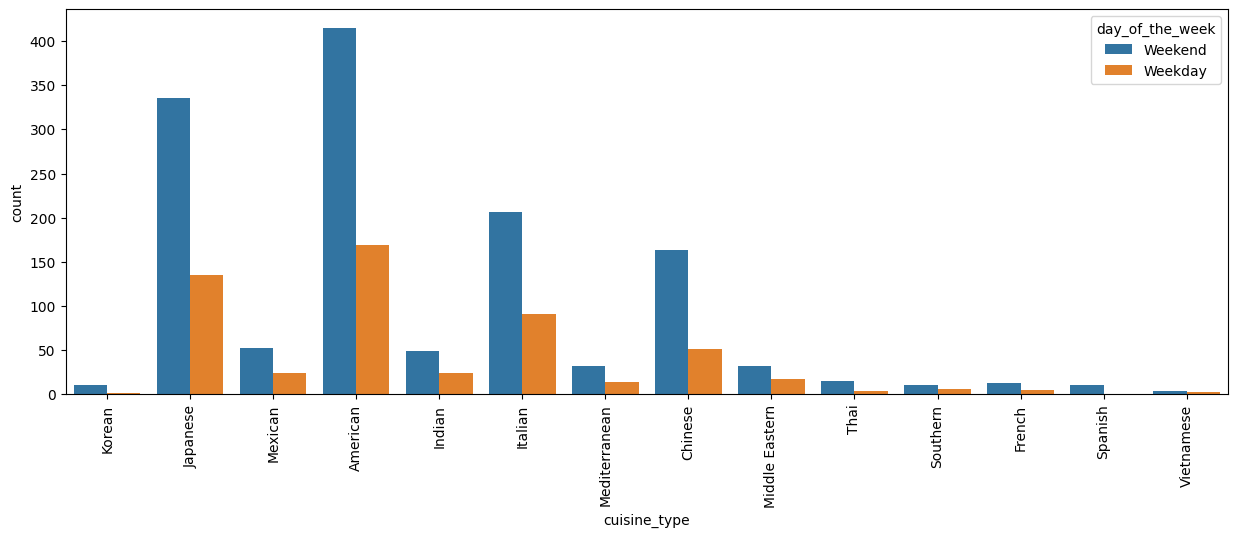

In [138]:
# Write the code here
# plotting number of orders by cuisine_type and day_of_the_week
plt.figure(figsize=(15,5))
plt.xticks(rotation=90)
sns.countplot(df, x='cuisine_type', hue='day_of_the_week');

#### Observations:
- American is the most popular cuisine on Weekends


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [139]:
# Write the code here
# filter the df for orders costing greater than 20 dollars and get count
orders_cost_more_than_20 = df[df['cost_of_the_order'] > 20].shape[0]

# calculating percent of orders costing greater than 20 dollars
percent_orders_cost_more_than_20 = (orders_cost_more_than_20/df.shape[0])*100

# print values
print(f"No. of orders cost more than 20 dollars: {orders_cost_more_than_20}")
print(f"Percentage of orders cost more than 20 dollars: {percent_orders_cost_more_than_20:.2f}%")

No. of orders cost more than 20 dollars: 555
Percentage of orders cost more than 20 dollars: 29.24%


#### Observations:
- 29.24% of the orders cost more than 20 dollars

### **Question 10**: What is the mean order delivery time? [1 mark]

In [140]:
# Write the code here
# find mean of delivery time rounded to 2 decimals
df['delivery_time'].mean().round(2)

np.float64(24.16)

#### Observations:
- Average order delivery time is 24.16 mins


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [141]:
# Write the code here
# find the customer_id counts and select top 3
df['customer_id'].value_counts().reset_index().head(3)

,customer_id,count
0,52832,13
1,47440,10
2,83287,9


#### Observations:
- IDs of top 3 most frequent customers are 52832, 47440, and 83287 with 13, 10 and 9 orders respectively.

## Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


#### Co-relation of Numeric values

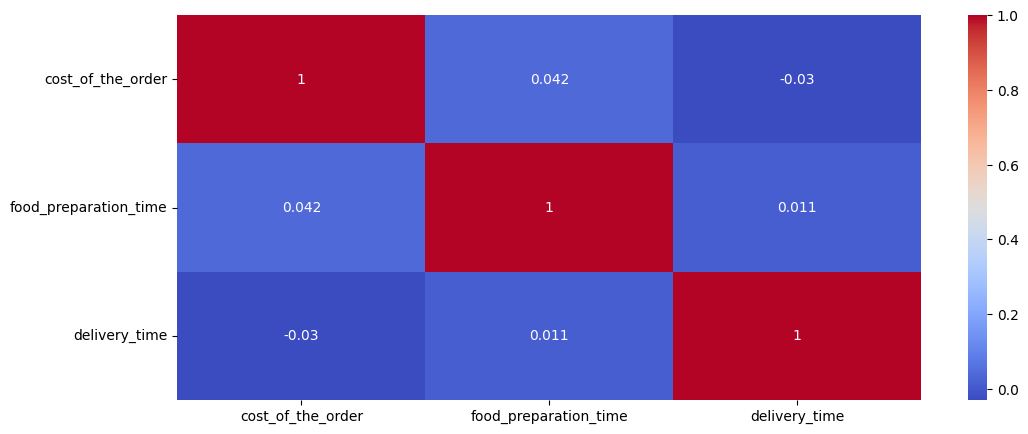

In [142]:
# Write the code here
# numeric column names list
cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']

# find correlation
correlation = df[cols].corr(numeric_only=True)

# plot heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm');

#### Observations:
There is no strong co-relation between the numerical variables 'cost_of_the_order', 'food_preparation_time', 'delivery_time'.

- **cost_of_the_order => food_preparation_time:** Very Weak Positive
- **cost_of_the_order => delivery_time:** Very Weak Negative
- **delivery_time => food_preparation_time:** Very Weak Positive


#### Rating and Total Order to Delivery Time

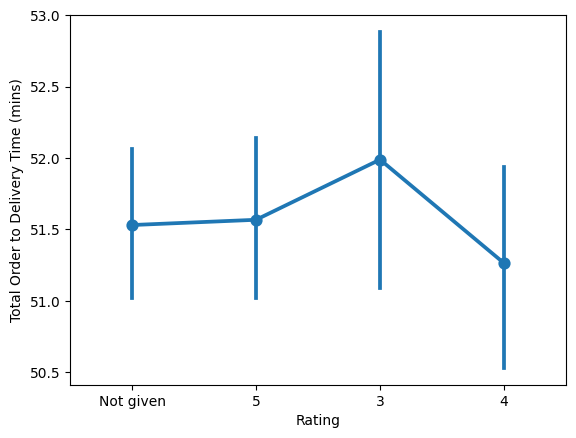

In [143]:
# pointplot to show relation between rating and delivery time
plt.xlabel('Rating')
plt.ylabel('Total Order to Delivery Time (mins)')
sns.pointplot(data=df, x='rating', y='total_time');

#### Observations
- Overall, ratings doesn’t strongly vary with fulfillment time
- Customers giving 4-star ratings tend to have slightly shorter fulfillment times
- Those giving 3-star ratings show more variability, possibly due to occasional delays or inconsistent experiences

#### Rating and Order Cost

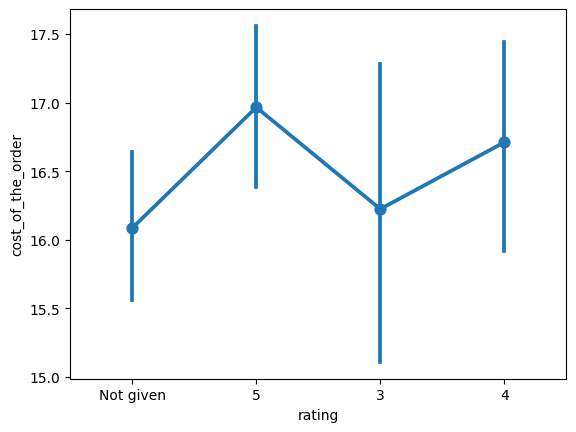

In [144]:
# pointplot to show relation between rating and order cost
sns.pointplot(data=df, x='rating', y='cost_of_the_order');

#### Observations
- Orders that received a "5" rating had the highest average cost, peaking at approximately 17.0 dollars
- Orders that received a "3" rating had the lowest average cost, around 16.2 dollars
- The highest ratings (4 and 5) generally correspond to a higher average order cost compared to the lowest rating (3)

#### Cuisine type and Order Cost

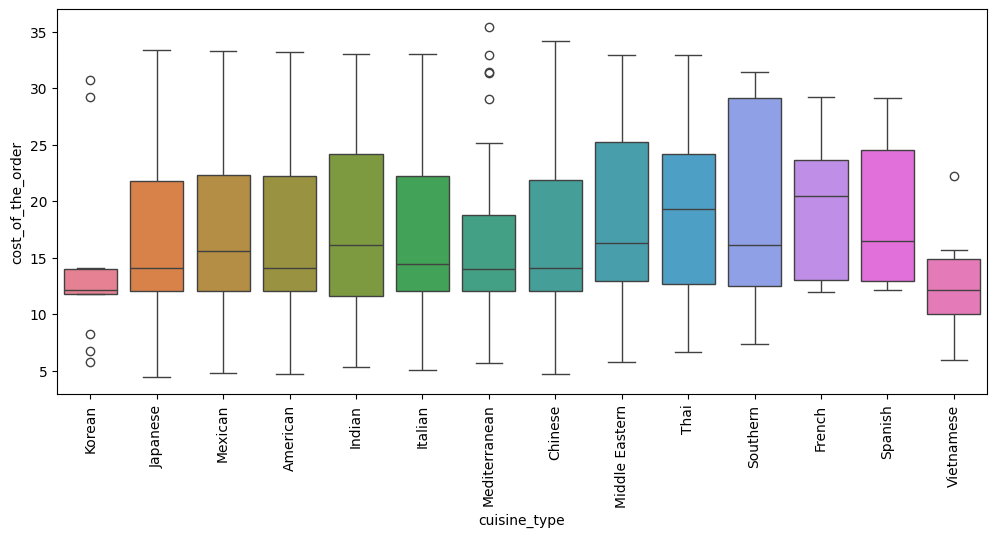

In [145]:
# boxplots to analyse order cost by cuisine types
plt.figure(figsize=(12,5))
plt.xticks(rotation=90)
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order', hue='cuisine_type');

#### Observations:
- **Highest Variability (Longest IQR):** Southern, Middle Eastern, and French cuisines have the widest boxes, suggesting the cost of the middle 50% of orders varies the most.

- **Lowest Variability (Shortest IQR):** Korean and Vietnamese cuisines have the narrowest boxes, indicating very consistent order costs.

- **Outliers:** Mediterranean, Korean, and Vietnamese cuisines show distinct outliers, where a few orders had a significantly higher or lower cost compared to the bulk of the data for that cuisine.

#### Cuisine type and Food preparation time

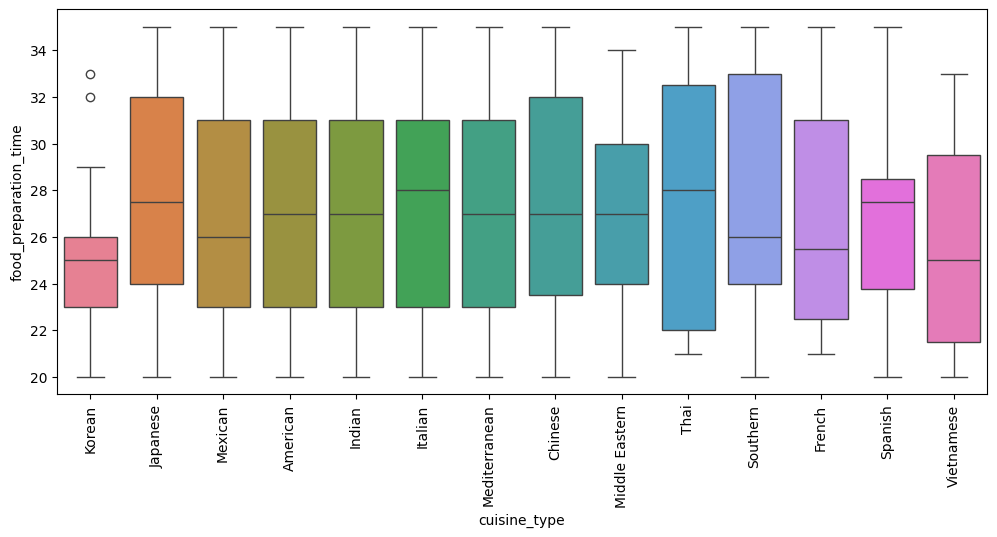

In [146]:
# boxplots to analyse food preparation time by cuisine types
plt.figure(figsize=(12,5))
plt.xticks(rotation=90)
sns.boxplot(data=df, x='cuisine_type', y='food_preparation_time', hue='cuisine_type');

#### Observations:
- **Fastest Median Preparation Time:** Thai cuisine has the lowest median preparation time, around 25 minutes.
- **Slowest Median Preparation Time:** Southern cuisine has the highest median preparation time, at approximately 26 minutes.
- **High Consistency in Median:** Most other cuisines, including Japanese, American, Indian, Italian, Mediterranean, Chinese, Middle Eastern, and French, show remarkable consistency, with median preparation times clustered tightly between 26.5 and 27.5 minutes.
- **Outliers:** Only Korean cuisine shows a distinct outlier point, indicating at least one order with a preparation time significantly longer than the rest of the data (around 33 minutes).

### Delivery time by Day of the week

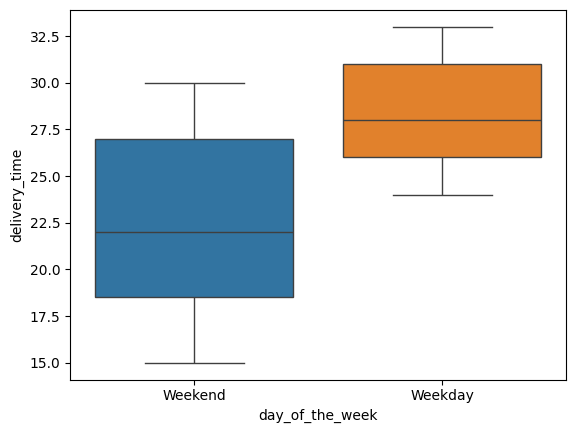

In [147]:
# boxplots to analyse delivery time by day of the week
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time', hue='day_of_the_week');

#### Observations:
- The median for Weekday delivery is higher than the median for Weekend delivery
- The delivery times are faster in the weekends but more consistent during the weekdays

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [148]:
# Write the code here
# filtering the rows with valid ratings
df_rated = data[data['rating'] != 'Not given'].copy()

# convert ratings dtype to int
df_rated['rating'] = df_rated['rating'].astype(int)

In [149]:
# Calculating rating counts and avg mean by restaurant name
df_rating_count_mean = df_rated.groupby('restaurant_name').agg({'rating': ['count', 'mean']}).reset_index()

# rename columns
df_rating_count_mean.columns = ['restaurant_name', 'rating_count', 'rating_mean']

# find the restaurants with more than 50 ratings and average rating of 4
df_restaurants_50_plus_rating_greater_than_mean_4 = df_rating_count_mean[(df_rating_count_mean['rating_count'] > 50) & (df_rating_count_mean['rating_mean'] > 4)]
df_restaurants_50_plus_rating_greater_than_mean_4.reset_index(drop=True, inplace=True)
df_restaurants_50_plus_rating_greater_than_mean_4

,restaurant_name,rating_count,rating_mean
0,Blue Ribbon Fried Chicken,64,4.33
1,Blue Ribbon Sushi,73,4.22
2,Shake Shack,133,4.28
3,The Meatball Shop,84,4.51


#### Observations:
Restaurants eligible for the promotional offer:
  1) Shake Shack
  2) The Meatball Shop
  3) Blue Ribbon Sushi
  4) Blue Ribbon Fried Chicken

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [150]:
# Write the code here
# function to calculate commission by order value
def cal_net_revenue(order_cost):
  if order_cost > 20:
    return order_cost * 0.25
  elif order_cost > 5:
    return order_cost * 0.15
  else:
    return order_cost * 0

# calculate commission by cost_of_the_order
df['net_revenue'] = df['cost_of_the_order'].apply(cal_net_revenue)
print(f"Net revenue generated by the company across all orders: ${df['net_revenue'].sum():.2f}")

Net revenue generated by the company across all orders: $6166.30


#### Observations:
The company generated a net revenue of \$6166.30 across the orders.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [151]:
# Write the code here
# filter the orders with total_time greater than 60 and get count
orders_more_than_60_mins = df[df['total_time'] > 60].shape[0]

# calculate percent of orders with total_time greater than 60 mins
percent_orders_more_than_60 = (orders_more_than_60_mins/df.shape[0])*100
print(f"No. of orders more than 60 mins: {orders_more_than_60_mins}")
print(f"Percentage of orders more than 60 mins: {percent_orders_more_than_60:.2f}%")

No. of orders more than 60 mins: 200
Percentage of orders more than 60 mins: 10.54%


#### Observations:
- 10.54% of the orders took more than 60 minutes for fulfillment.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [152]:
# group by day of the week and find mean rounded to 2 decimals
df.groupby('day_of_the_week')['delivery_time'].mean().round(2).reset_index()

,day_of_the_week,delivery_time
0,Weekday,28.34
1,Weekend,22.47


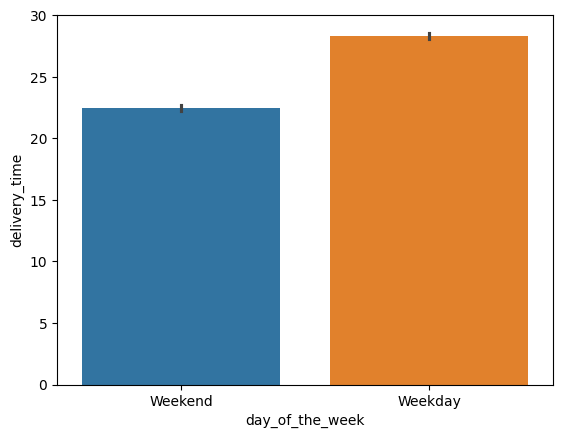

In [153]:
# Write the code here
# visualize delivery time by day of the week
sns.barplot(data=df, x='day_of_the_week', y='delivery_time', hue='day_of_the_week');

#### Observations:
- The mean delivery time during the weekdays (28.34 mins) is higher than the mean delivery time during the weekend (22.47 mins) by around 6 minutes.

## Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

#### Conclusions:
- The dataset contains information about nearly 1900 food orders, including details about the restaurant, cuisine, cost, day of the week, rating, and time taken for preparation and delivery.

- A significant portion of orders (38.78%) were not rated by customers.

- The average cost of an order is around \$16.50 with most order costs between \$10 and \$20.  

- Food preparation times are relatively consistent across restaurants, averaging about 27 minutes.

- Delivery times average around 24 minutes but are significantly faster on weekends (22.47 minutes) compared to weekdays (28.34 minutes).

- The total time from order placement to delivery averages around 51.5 minutes.

- Approximately 10.54% of orders take longer than 60 minutes for the entire process.

- A small number of restaurants (top 5) fulfill a substantial portion of the orders (34%).

- American, Japanese, Italian, and Chinese cuisines are the most popular.

- There is no strong correlation between numerical variables like order cost, preparation time, and delivery time.

- While not a strong relationship, higher ratings tend to be associated with slightly higher average order costs.

- Four restaurants (Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken) meet the criteria for the promotional offer (more than 50 ratings with an average rating above 4).

- The company's net revenue from all orders is \$6166.30.

#### Recommendations:

- **Address unrated orders:** Investigate why a large percentage of orders are not being rated. Implement strategies to encourage customers to leave feedback, such as push notifications, incentives, or simplifying the rating process. This feedback is crucial for identifying areas of improvement.

- **Optimize weekday deliveries:** The analysis shows that weekday deliveries take longer than weekend deliveries. Explore the reasons behind this difference. It could be related to traffic patterns, staffing levels, or restaurant preparation times during the week. Implement solutions to reduce weekday delivery times, such as optimizing delivery routes, partnering with more delivery personnel during peak weekday hours, or working with restaurants to improve their weekday preparation efficiency.

- **Leverage popular cuisines and restaurants:** Focus marketing efforts on the most popular cuisines (American, Japanese, Italian, Chinese) and the top-performing restaurants (Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, Parm). Consider highlighting these options in the app and through promotional campaigns.
- **Promotional offers for high-rated restaurants:** Utilize the promotional offer for restaurants with high ratings and a significant number of reviews. This can attract more customers to these well-regarded establishments and potentially increase order volume.

- **Analyze customer behavior for frequent customers:** Further analyze the behavior of the top 3 most frequent customers to understand their preferences and ordering patterns. This information can be used to develop targeted promotions or loyalty programs to retain these valuable customers.

- **Investigate outlier costs and preparation times:** While most order costs and preparation times are within a reasonable range, investigate any significant outliers. This could indicate potential issues with specific restaurants or order types that need to be addressed.

---